 ### Análise Completa de Acidentes de Trânsito (2017-2024)
* **Disciplina:** Ciência de Dados - UFG
* **Base de dados:** DATATRAN - Acidentes de trânsito em rodovias federais (2017-2024)

####  Objetivos
- Explorar padrões e tendências em acidentes de trânsito
- Implementar Feature Engineering avançado
- Identificar fatores de risco e insights acionáveis

####  Principais Análises
1. **Business Understanding** - Contexto e perguntas de negócio
2. **Data Understanding** - Exploração e qualidade dos dados
3. **Data Preparation** - Limpeza e transformação
4. **Feature Engineering** - Criação de novas variáveis
5. **Exploratory Data Analysis** - Análises exploratórias 
---

### Business Understanding

#### Contexto do Problema

#### O que é o DATATRAN?

O DATATRAN é a base oficial de dados da **Polícia Rodoviária Federal (PRF)** que registra informações sobre acidentes de trânsito ocorridos nas rodovias federais do Brasil. Esta base contém dados detalhados sobre:

- **Características dos acidentes:** tipo, causa, condições climáticas, estado da pista
- **Informações temporais:** data, hora, dia da semana
- **Localização:** estado, município, rodovia, quilômetro
- **Consequências:** número de feridos, mortos, veículos envolvidos
- **Dados das pessoas envolvidas:** idade, sexo, condição (condutor, passageiro, pedestre)

#### Problemas de Negócio

1. **Impacto Social:** Acidentes de trânsito são uma das principais causas de morte no Brasil
2. **Impacto Econômico:** Custos com saúde pública, perda de produtividade, danos materiais
3. **Segurança Pública:** Necessidade de políticas preventivas eficazes
4. **Planejamento de Infraestrutura:** Identificação de pontos críticos para investimento

#### Stakeholders

- **Governo:** Ministério da Infraestrutura, PRF, DNIT
- **Sociedade Civil:** Motoristas, pedestres, famílias das vítimas
- **Órgãos de Saúde:** SUS, hospitais, serviços de emergência
- **Seguradoras:** Análise de risco e precificação
- **Pesquisadores:** Estudos acadêmicos e desenvolvimento de políticas

#### Perguntas de Negócio

1. **Fatores de Risco:** Quais são os principais fatores que contribuem para acidentes graves?
2. **Padrões Temporais:** Existe sazonalidade nos acidentes (horário, dia da semana, mês)?
3. **Distribuição Geográfica:** Quais rodovias e regiões apresentam maior risco?
4. **Impacto COVID-19:** Como a pandemia (2020-2021) afetou os padrões de acidentes?
5. **Perfil das Vítimas:** Qual o perfil das vítimas mais vulneráveis?
6. **Efetividade de Políticas:** Quais intervenções podem ser mais eficazes?

#### Pesquisas Futuras

- **Específico:** Identificar padrões em acidentes de trânsito em rodovias federais
- **Mensurável:** Quantificar fatores de risco e impactos
- **Atingível:** Usar dados disponíveis do DATATRAN (2017-2024)
- **Relevante:** Contribuir para políticas de segurança no trânsito
- **Temporal:** Análise de 8 anos de dados (2017-2024)

---

## Data Understanding

#### Exploração Inicial dos Dados

In [1]:
# Importando as bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import os
import glob

# --- Configurações de Visualização ---
%matplotlib inline
pd.set_option('display.max_columns', None)
sns.set_theme(style="darkgrid")

In [2]:

# --- Definição dos Caminhos ---
# Pega o diretório atual onde o script está rodando
current_dir = os.path.dirname(os.path.abspath('__file__')) 
# Define o caminho para a pasta de dados brutos
raw_data_path = os.path.join(current_dir, '..', 'data', 'raw_data')
# Define o caminho para a pasta de dados processados
processed_data_path = os.path.join(current_dir, '..', 'data', 'processed_data')

# Criando o diretório 'processed_data' se ele não existir
os.makedirs(processed_data_path, exist_ok=True)

# --- Carregamento dos Dados ---

# Listando todos os arquivos .csv disponíveis no diretório
csv_files = glob.glob(os.path.join(raw_data_path, '*.csv'))
print(f" Arquivos encontrados: {len(csv_files)}")
for file in sorted(csv_files):
    print(f"   - {os.path.basename(file)}")

# Lista para armazenar cada DataFrame individual antes de unir
all_dfs = []

# Loop para ler, tratar e armazenar cada arquivo CSV
print("\n Carregando e processando todos os arquivos...")
for file_path in sorted(csv_files):
    file_name = os.path.basename(file_path)
    try:
        # Tenta ler o arquivo com a codificação 'latin-1' e separador ';'
        # Esses são padrões comuns para arquivos de dados governamentais no Brasil.
        df_temp = pd.read_csv(
            file_path, 
            encoding='latin-1', 
            sep=';'
        )
        # Adiciona uma coluna 'ano' baseada no nome do arquivo para fácil identificação
        df_temp['ano'] = file_name.replace('datatran', '').replace('.csv', '')
        
        all_dfs.append(df_temp)
        print(f"  ✅ Sucesso ao ler: {file_name}")
        
    except Exception as e:
        # Se ocorrer um erro, informa qual arquivo falhou e o motivo
        print(f"  ❌ Falha ao ler o arquivo {file_name}. Erro: {e}")

# --- Consolidação dos Dados ---

# Verifica se algum DataFrame foi carregado antes de tentar concatenar
if all_dfs:
    # Concatena (une) todos os DataFrames da lista em um único DataFrame
    # ignore_index=True reinicia o índice do DataFrame final
    df = pd.concat(all_dfs, ignore_index=True)
    
    print("\n Todos os arquivos foram carregados e combinados com sucesso!")
    print(f"\nO DataFrame final possui {df.shape[0]:,} linhas e {df.shape[1]} colunas.")
    
    # Exibe as 5 primeiras linhas do DataFrame consolidado
    print("\n--- Visualizando as primeiras 5 linhas dos dados combinados ---")
    display(df.head())
    
    # Exibe informações gerais sobre o DataFrame
    print("\n--- Informações Gerais do DataFrame ---")
    df.info()
    
else:
    print("\n⚠️ Nenhum arquivo foi carregado. O DataFrame final está vazio.")

 Arquivos encontrados: 8
   - datatran2017.csv
   - datatran2018.csv
   - datatran2019.csv
   - datatran2020.csv
   - datatran2021.csv
   - datatran2022.csv
   - datatran2023.csv
   - datatran2024.csv

 Carregando e processando todos os arquivos...
  ✅ Sucesso ao ler: datatran2017.csv
  ✅ Sucesso ao ler: datatran2018.csv
  ✅ Sucesso ao ler: datatran2019.csv
  ✅ Sucesso ao ler: datatran2020.csv
  ✅ Sucesso ao ler: datatran2021.csv
  ✅ Sucesso ao ler: datatran2022.csv
  ✅ Sucesso ao ler: datatran2023.csv
  ✅ Sucesso ao ler: datatran2024.csv

 Todos os arquivos foram carregados e combinados com sucesso!

O DataFrame final possui 560,138 linhas e 31 colunas.

--- Visualizando as primeiras 5 linhas dos dados combinados ---


,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,classificacao_acidente,fase_dia,sentido_via,condicao_metereologica,tipo_pista,tracado_via,uso_solo,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop,ano
0,17.0,2017-01-01,domingo,01:45:00,RS,116,"34,9",VACARIA,Defeito Mecânico no Veículo,Colisão traseira,Com Vítimas Feridas,Plena Noite,Decrescente,Céu Claro,Simples,Reta,Não,6,0,4,0,2,0,4,2,"-28,5071196","-50,941176",SPRF-RS,DEL05-RS,UOP03-DEL05-RS,2017
1,20.0,2017-01-01,domingo,01:00:00,PR,376,636,TIJUCAS DO SUL,Velocidade Incompatível,Saída de leito carroçável,Com Vítimas Fatais,Plena Noite,Crescente,Garoa/Chuvisco,Dupla,Curva,Não,2,1,0,0,1,0,0,2,"-25,754","-49,1266",SPRF-PR,DEL01-PR,DEL7/1-UOP08/PR,2017
2,69.0,2017-01-01,domingo,04:40:00,BA,101,65,ENTRE RIOS,Condutor Dormindo,Colisão frontal,Com Vítimas Fatais,Amanhecer,Decrescente,Nublado,Simples,Curva,Não,5,1,1,1,2,0,2,2,"-11,9618","-38,0953",SPRF-BA,DEL01-BA,UOP04-DEL01-BA,2017
3,106.0,2017-01-01,domingo,06:30:00,PA,316,"72,5",CASTANHAL,Falta de Atenção à Condução,Colisão lateral,Com Vítimas Fatais,Amanhecer,Decrescente,Céu Claro,Simples,Reta,Não,4,1,0,0,3,0,0,3,"-1,2899799","-47,83483207",SPRF-PA,DEL01-PA,DEL19/1-UOP02/PA,2017
4,109.0,2017-01-01,domingo,09:00:00,GO,20,"220,5",POSSE,Defeito na Via,Colisão com objeto estático,NaN,Pleno dia,Decrescente,Céu Claro,Simples,Declive,Não,4,0,2,1,0,1,3,2,"-14,14220931","-46,32258922",SPRF-DF,DEL02-DF,UOP03-DEL02-DF,2017



--- Informações Gerais do DataFrame ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 560138 entries, 0 to 560137
Data columns (total 31 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      560138 non-null  float64
 1   data_inversa            560138 non-null  object 
 2   dia_semana              560138 non-null  object 
 3   horario                 560138 non-null  object 
 4   uf                      560138 non-null  object 
 5   br                      560138 non-null  int64  
 6   km                      560138 non-null  object 
 7   municipio               560138 non-null  object 
 8   causa_acidente          560138 non-null  object 
 9   tipo_acidente           560097 non-null  object 
 10  classificacao_acidente  560129 non-null  object 
 11  fase_dia                560138 non-null  object 
 12  sentido_via             560138 non-null  object 
 13  condicao_metereologica  560138 no

In [3]:
# Verificar estatísticas descritivas básicas
df.describe(include='all')

,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,classificacao_acidente,fase_dia,sentido_via,condicao_metereologica,tipo_pista,tracado_via,uso_solo,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop,ano
count,560138.000000,560138,560138,560138,560138,560138.000000,560138,560138,560138,560097,560129,560138,560138,560138,560138,560138,560138,560138.000000,560138.000000,560138.000000,560138.000000,560138.000000,560138.000000,560138.000000,560138.000000,560138,560138,560111,559923,559742,560138
unique,NaN,2922,7,1440,27,NaN,9864,2120,91,21,3,4,3,10,3,1183,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,271298,271952,28,154,433,8
top,NaN,2017-12-23,sábado,19:00:00,MG,NaN,1,BRASILIA,Falta de Atenção à Condução,Colisão traseira,Com Vítimas Feridas,Pleno dia,Crescente,Céu Claro,Simples,Reta,Não,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"-27,59193546","-48,61824557",SPRF-MG,DEL01-PR,UOP01-DEL01-SC,2017
freq,NaN,449,92775,8130,73847,NaN,2386,8028,107788,104966,406744,306841,298897,331349,280964,332677,317295,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,356,356,73655,24601,9366,89567
mean,326860.988076,NaN,NaN,NaN,NaN,212.331274,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.525467,0.079943,0.843173,0.263080,1.044653,0.374627,1.106252,1.959699,NaN,NaN,NaN,NaN,NaN,NaN
std,191092.480991,NaN,NaN,NaN,NaN,130.645586,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.020465,0.337474,1.086182,0.608292,1.550261,0.801450,1.216756,1.085935,NaN,NaN,NaN,NaN,NaN,NaN
min,8.000000,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,162113.250000,NaN,NaN,NaN,NaN,101.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN
50%,321920.500000,NaN,NaN,NaN,NaN,163.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,2.000000,NaN,NaN,NaN,NaN,NaN,NaN
75%,499143.750000,NaN,NaN,NaN,NaN,324.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,2.000000,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Pré-processamento dos Dados

Nesta seção, realizamos o pré-processamento dos dados para preparar as análises, incluindo:
- Conversão de tipos de dados
- Tratamento de valores ausentes
- Criação de novas features
- Padronização de categorias

In [4]:
# Conversão de datas
df['data_inversa'] = pd.to_datetime(df['data_inversa'], errors='coerce')
df['year'] = df['data_inversa'].dt.year
df['month'] = df['data_inversa'].dt.month
df['day'] = df['data_inversa'].dt.day
df['weekday'] = df['data_inversa'].dt.dayofweek  # 0 = Monday, 6 = Sunday

# Conversão de horário e criação de classificação de período do dia
df['horario'] = pd.to_datetime(df['horario'], format='%H:%M:%S', errors='coerce')
df['HORA'] = df['horario'].dt.hour.fillna(-1).astype(int)

# Classificação em períodos do dia (madrugada, manhã, tarde, noite)
bins = [-1, 4, 11, 17, 23]  # limites de hora: -1, 4, 11, 17, 23
labels = ['MADRUGADA', 'MANHÃ', 'TARDE', 'NOITE']

df['PERIODO_DIA'] = pd.cut(
    df['HORA'],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=True
)

# Substituir valores fora dos intervalos com 'DESCONHECIDO'
df['PERIODO_DIA'] = df['PERIODO_DIA'].cat.add_categories(['DESCONHECIDO'])
df.loc[df['HORA'] < 0, 'PERIODO_DIA'] = 'DESCONHECIDO'
df.loc[df['HORA'] >= 24, 'PERIODO_DIA'] = 'DESCONHECIDO'

# Conversão de colunas numéricas (tratando separador decimal)
for col in ['km', 'latitude', 'longitude']:
    df[col] = (df[col].astype(str)
              .str.replace(',', '.')
              .astype(float, errors='ignore'))

# Criação de novas features
df['TOTAL_FERIDOS'] = df['feridos_leves'] + df['feridos_graves']
df['mortos'] = df['mortos'].fillna(0).astype(int)
df['veiculos'] = df['veiculos'].fillna(0).astype(int)

# Preenchimento de valores ausentes em colunas numéricas
fill_numeric = ['km', 'latitude', 'longitude', 'veiculos', 'pessoas', 'TOTAL_FERIDOS', 'mortos']
for col in fill_numeric:
    df[col] = df[col].fillna(df[col].median())

# Preenchimento de valores ausentes em colunas categóricas
categorical_cols = [
    'uf', 'municipio', 'causa_acidente', 'tipo_acidente',
    'sentido_via', 'condicao_metereologica', 'tipo_pista',
    'tracado_via', 'uso_solo', 'PERIODO_DIA', 'dia_semana'
]
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Normalização da condição meteorológica para caixa alta
df['condicao_metereologica'] = df['condicao_metereologica'].str.upper()

# Calcular taxa de mortalidade
df['TAXA_MORTALIDADE'] = df['mortos'] / df['pessoas'].replace(0, np.nan)
df['TAXA_MORTALIDADE'] = df['TAXA_MORTALIDADE'].fillna(0)

# Exibir resultado do pré-processamento
df.head()

,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,classificacao_acidente,fase_dia,sentido_via,condicao_metereologica,tipo_pista,tracado_via,uso_solo,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop,ano,year,month,day,weekday,HORA,PERIODO_DIA,TOTAL_FERIDOS,TAXA_MORTALIDADE
0,17.0,2017-01-01,domingo,1900-01-01 01:45:00,RS,116,34.9,VACARIA,Defeito Mecânico no Veículo,Colisão traseira,Com Vítimas Feridas,Plena Noite,Decrescente,CÉU CLARO,Simples,Reta,Não,6,0,4,0,2,0,4,2,-28.507120,-50.941176,SPRF-RS,DEL05-RS,UOP03-DEL05-RS,2017,2017,1,1,6,1,MADRUGADA,4,0.00
1,20.0,2017-01-01,domingo,1900-01-01 01:00:00,PR,376,636.0,TIJUCAS DO SUL,Velocidade Incompatível,Saída de leito carroçável,Com Vítimas Fatais,Plena Noite,Crescente,GAROA/CHUVISCO,Dupla,Curva,Não,2,1,0,0,1,0,0,2,-25.754000,-49.126600,SPRF-PR,DEL01-PR,DEL7/1-UOP08/PR,2017,2017,1,1,6,1,MADRUGADA,0,0.50
2,69.0,2017-01-01,domingo,1900-01-01 04:40:00,BA,101,65.0,ENTRE RIOS,Condutor Dormindo,Colisão frontal,Com Vítimas Fatais,Amanhecer,Decrescente,NUBLADO,Simples,Curva,Não,5,1,1,1,2,0,2,2,-11.961800,-38.095300,SPRF-BA,DEL01-BA,UOP04-DEL01-BA,2017,2017,1,1,6,4,MADRUGADA,2,0.20
3,106.0,2017-01-01,domingo,1900-01-01 06:30:00,PA,316,72.5,CASTANHAL,Falta de Atenção à Condução,Colisão lateral,Com Vítimas Fatais,Amanhecer,Decrescente,CÉU CLARO,Simples,Reta,Não,4,1,0,0,3,0,0,3,-1.289980,-47.834832,SPRF-PA,DEL01-PA,DEL19/1-UOP02/PA,2017,2017,1,1,6,6,MANHÃ,0,0.25
4,109.0,2017-01-01,domingo,1900-01-01 09:00:00,GO,20,220.5,POSSE,Defeito na Via,Colisão com objeto estático,NaN,Pleno dia,Decrescente,CÉU CLARO,Simples,Declive,Não,4,0,2,1,0,1,3,2,-14.142209,-46.322589,SPRF-DF,DEL02-DF,UOP03-DEL02-DF,2017,2017,1,1,6,9,MANHÃ,3,0.00


## 3. Análise de Tendência Temporal

Análise da evolução dos acidentes e mortes ao longo dos anos, meses e dias da semana

In [5]:
# Análise por ano - tendência temporal
dados_anuais = df.groupby('year').agg({
    'year': 'count',
    'mortos': 'sum',
    'TOTAL_FERIDOS': 'sum'
}).rename(columns={'year': 'total_acidentes'}).reset_index()

# Calcular taxa de mortalidade por ano
dados_anuais['media_mortos_por_acidente'] = dados_anuais['mortos'] / dados_anuais['total_acidentes']

# Calcular variação percentual ano a ano
dados_anuais['variacao_percentual'] = dados_anuais['total_acidentes'].pct_change() * 100

# Criar gráfico com duas escalas (acidentes e mortes)
fig = make_subplots(specs=[[{"secondary_y": True}]])

# Adicionar série de acidentes
fig.add_trace(
    go.Scatter(
        x=dados_anuais['year'],
        y=dados_anuais['total_acidentes'],
        name="Total de Acidentes",
        line=dict(color="#0088FE", width=3),
        mode="lines+markers"
    ),
    secondary_y=False,
)

# Adicionar série de mortes
fig.add_trace(
    go.Scatter(
        x=dados_anuais['year'],
        y=dados_anuais['mortos'],
        name="Total de Mortos",
        line=dict(color="#FF4444", width=3),
        mode="lines+markers"
    ),
    secondary_y=True,
)

# Adicionar série de feridos
fig.add_trace(
    go.Scatter(
        x=dados_anuais['year'],
        y=dados_anuais['TOTAL_FERIDOS'],
        name="Total de Feridos",
        line=dict(color="#FFBB28", width=3),
        mode="lines+markers"
    ),
    secondary_y=True,
)

# Configurar eixos e título
fig.update_layout(
    title="Evolução Anual de Acidentes, Mortes e Feridos nas Rodovias Federais",
    xaxis_title="Ano",
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="center", x=0.5),
    template="plotly_white",
    height=600,
    hovermode="x unified"
)

fig.update_yaxes(title_text="Número de Acidentes", secondary_y=False)
fig.update_yaxes(title_text="Número de Mortos e Feridos", secondary_y=True)

fig.show()

In [6]:
# Análise de tendência da taxa de mortalidade
fig = px.line(dados_anuais, x="year", y="media_mortos_por_acidente", 
             title="Evolução da Taxa de Mortalidade por Acidente",
             labels={"year": "Ano", "media_mortos_por_acidente": "Média de Mortes por Acidente"},
             markers=True, line_shape="linear")

fig.update_traces(line=dict(color="#FF4444", width=3), marker=dict(size=8))
fig.update_layout(template="plotly_white", height=400)
fig.show()

In [7]:
# Análise por mês - padrão sazonal
dados_mensais = df.groupby('month').agg({
    'month': 'count',
    'mortos': 'sum',
    'TOTAL_FERIDOS': 'sum'
}).rename(columns={'month': 'total_acidentes'}).reset_index()

# Mapear números dos meses para nomes
meses = {1: 'Jan', 2: 'Fev', 3: 'Mar', 4: 'Abr', 5: 'Mai', 6: 'Jun',
         7: 'Jul', 8: 'Ago', 9: 'Set', 10: 'Out', 11: 'Nov', 12: 'Dez'}
dados_mensais['mes'] = dados_mensais['month'].map(meses)

# Ordenar por mês
dados_mensais = dados_mensais.sort_values('month')

# Criar gráfico
fig = go.Figure()

# Adicionar série de acidentes
fig.add_trace(go.Bar(
    x=dados_mensais['mes'],
    y=dados_mensais['total_acidentes'],
    name='Total de Acidentes',
    marker_color='#0088FE',
    opacity=0.8
))

fig.add_trace(go.Scatter(
    x=dados_mensais['mes'],
    y=dados_mensais['mortos'],
    name='Total de Mortos',
    mode='lines+markers',
    line=dict(color='#FF4444', width=3),
    marker=dict(size=8)
))

fig.update_layout(
    title="Acidentes e Mortes por Mês nas Rodovias Federais",
    xaxis_title="Mês",
    yaxis_title="Quantidade",
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="center", x=0.5),
    template="plotly_white",
    height=500
)

fig.show()

In [8]:
# Análise por dia da semana
dados_semanais = df.groupby('dia_semana').agg({
    'dia_semana': 'count',
    'mortos': 'sum',
    'TOTAL_FERIDOS': 'sum'
}).rename(columns={'dia_semana': 'total_acidentes'}).reset_index()

# Ordenar os dias da semana em ordem cronológica
ordem_dias = {'Segunda-feira': 0, 'Terça-feira': 1, 'Quarta-feira': 2, 'Quinta': 3, 
              'Quinta-feira': 3, 'Sexta': 4, 'Sexta-feira': 4, 'Sábado': 5, 'Domingo': 6}

dados_semanais['ordem'] = dados_semanais['dia_semana'].map(ordem_dias)
dados_semanais = dados_semanais.sort_values('ordem')

# Criar gráfico
fig = go.Figure()

# Adicionar série de acidentes
fig.add_trace(go.Bar(
    x=dados_semanais['dia_semana'],
    y=dados_semanais['total_acidentes'],
    name='Total de Acidentes',
    marker_color='#0088FE',
    opacity=0.7
))

fig.add_trace(go.Scatter(
    x=dados_semanais['dia_semana'],
    y=dados_semanais['mortos'],
    name='Total de Mortos',
    mode='lines+markers',
    line=dict(color='#FF4444', width=3),
    marker=dict(size=8)
))

fig.update_layout(
    title="Acidentes e Mortes por Dia da Semana nas Rodovias Federais",
    xaxis_title="Dia da Semana",
    yaxis_title="Quantidade",
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="center", x=0.5),
    template="plotly_white",
    height=500
)

fig.show()

## 4. Análise por Hora do Dia

In [9]:
# Análise por hora do dia
dados_horas = df.groupby('HORA').agg({
    'HORA': 'count',
    'mortos': 'sum',
    'TOTAL_FERIDOS': 'sum'
}).rename(columns={'HORA': 'total_acidentes'}).reset_index()

# Calcular percentual de acidentes por hora
total_acidentes = dados_horas['total_acidentes'].sum()
dados_horas['percentual'] = (dados_horas['total_acidentes'] / total_acidentes) * 100

# Ordenar por hora
dados_horas = dados_horas.sort_values('HORA')

# Criar gráfico de área para acidentes e linha para mortes
fig = make_subplots(specs=[[{"secondary_y": True}]])

# Adicionar área para acidentes
fig.add_trace(
    go.Scatter(
        x=dados_horas['HORA'],
        y=dados_horas['total_acidentes'],
        name="Total de Acidentes",
        fill='tozeroy',
        fillcolor='rgba(0, 136, 254, 0.3)',
        line=dict(color="#0088FE", width=2),
        mode="lines"
    ),
    secondary_y=False,
)

# Adicionar linha para mortes
fig.add_trace(
    go.Scatter(
        x=dados_horas['HORA'],
        y=dados_horas['mortos'],
        name="Total de Mortos",
        line=dict(color="#FF4444", width=3),
        mode="lines+markers"
    ),
    secondary_y=True,
)

# Configurar eixos e título
fig.update_layout(
    title="Distribuição de Acidentes e Mortes por Hora do Dia",
    xaxis=dict(
        title="Hora do Dia",
        tickmode='array',
        tickvals=list(range(0, 24)),
        ticktext=[f"{i}h" for i in range(0, 24)]
    ),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="center", x=0.5),
    template="plotly_white",
    height=500,
    hovermode="x unified"
)

fig.update_yaxes(title_text="Número de Acidentes", secondary_y=False)
fig.update_yaxes(title_text="Número de Mortos", secondary_y=True)

fig.show()

In [10]:
# Análise por período do dia
dados_periodos = df.groupby('PERIODO_DIA').agg({
    'PERIODO_DIA': 'count',
    'mortos': 'sum',
    'TOTAL_FERIDOS': 'sum'
}).rename(columns={'PERIODO_DIA': 'total_acidentes'}).reset_index()

# Calcular taxa de mortalidade por período
dados_periodos['taxa_mortalidade'] = dados_periodos['mortos'] / dados_periodos['total_acidentes'] * 100

# Ordenar períodos em ordem cronológica
ordem_periodos = {'MADRUGADA': 0, 'MANHÃ': 1, 'TARDE': 2, 'NOITE': 3, 'DESCONHECIDO': 4}
dados_periodos['ordem'] = dados_periodos['PERIODO_DIA'].map(ordem_periodos)
dados_periodos = dados_periodos.sort_values('ordem')

# Criar gráfico
fig = make_subplots(specs=[[{"secondary_y": True}]])

# Adicionar barras para acidentes
fig.add_trace(
    go.Bar(
        x=dados_periodos['PERIODO_DIA'],
        y=dados_periodos['total_acidentes'],
        name="Total de Acidentes",
        marker_color="#0088FE",
        opacity=0.8
    ),
    secondary_y=False,
)

# Adicionar linha para taxa de mortalidade
fig.add_trace(
    go.Scatter(
        x=dados_periodos['PERIODO_DIA'],
        y=dados_periodos['taxa_mortalidade'],
        name="Taxa de Mortalidade (%)",
        line=dict(color="#FF4444", width=3),
        mode="lines+markers",
        marker=dict(size=10)
    ),
    secondary_y=True,
)

# Configurar eixos e título
fig.update_layout(
    title="Acidentes e Taxa de Mortalidade por Período do Dia",
    xaxis_title="Período do Dia",
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="center", x=0.5),
    template="plotly_white",
    height=500
)

fig.update_yaxes(title_text="Número de Acidentes", secondary_y=False)
fig.update_yaxes(title_text="Taxa de Mortalidade (%)", secondary_y=True)

fig.show()

C:\Users\Willgnner\AppData\Local\Temp\ipykernel_2808\2835481404.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



## 5. Análise por Tipo e Causa de Acidente

In [11]:
# Analisar tipos de acidentes
dados_tipos = df.groupby('tipo_acidente').agg({
    'tipo_acidente': 'count',
    'mortos': 'sum',
}).rename(columns={'tipo_acidente': 'total_acidentes'}).reset_index()

# Calcular média de mortos por acidente para cada tipo
dados_tipos['media_mortos'] = dados_tipos['mortos'] / dados_tipos['total_acidentes']

# Calcular percentual do total de acidentes
dados_tipos['percentual'] = (dados_tipos['total_acidentes'] / dados_tipos['total_acidentes'].sum()) * 100

# Ordenar por total de acidentes (decrescente)
dados_tipos = dados_tipos.sort_values('total_acidentes', ascending=False)

# Pegar os 10 tipos mais comuns
top_tipos = dados_tipos.head(10).copy()

# Criar gráfico
fig = make_subplots(specs=[[{"secondary_y": True}]])

# Adicionar barras para total de acidentes
fig.add_trace(
    go.Bar(
        x=top_tipos['tipo_acidente'],
        y=top_tipos['total_acidentes'],
        name="Total de Acidentes",
        marker_color="#0088FE"
    ),
    secondary_y=False,
)

# Adicionar linha para média de mortos
fig.add_trace(
    go.Scatter(
        x=top_tipos['tipo_acidente'],
        y=top_tipos['media_mortos'],
        name="Média de Mortos por Acidente",
        line=dict(color="#FF4444", width=3),
        mode="lines+markers"
    ),
    secondary_y=True,
)

# Configurar eixos e título
fig.update_layout(
    title="Top 10 Tipos de Acidentes - Total e Média de Mortos",
    xaxis=dict(
        title="Tipo de Acidente",
        tickangle=45
    ),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="center", x=0.5),
    template="plotly_white",
    height=600,
    margin=dict(b=150)
)

fig.update_yaxes(title_text="Número de Acidentes", secondary_y=False)
fig.update_yaxes(title_text="Média de Mortos por Acidente", secondary_y=True)

fig.show()

In [12]:
# Analisar causas dos acidentes
dados_causas = df.groupby('causa_acidente').agg({
    'causa_acidente': 'count',
    'mortos': 'sum',
}).rename(columns={'causa_acidente': 'total_acidentes'}).reset_index()

# Calcular média de mortos por acidente para cada causa
dados_causas['media_mortos'] = dados_causas['mortos'] / dados_causas['total_acidentes']

# Calcular percentual do total de acidentes
dados_causas['percentual'] = (dados_causas['total_acidentes'] / dados_causas['total_acidentes'].sum()) * 100

# Ordenar por total de acidentes (decrescente)
dados_causas = dados_causas.sort_values('total_acidentes', ascending=False)

# Pegar as 10 causas mais comuns
top_causas = dados_causas.head(10).copy()

# Criar gráfico
fig = make_subplots(specs=[[{"secondary_y": True}]])

# Adicionar barras para total de acidentes
fig.add_trace(
    go.Bar(
        x=top_causas['causa_acidente'],
        y=top_causas['total_acidentes'],
        name="Total de Acidentes",
        marker_color="#0088FE"
    ),
    secondary_y=False,
)

# Adicionar linha para média de mortos
fig.add_trace(
    go.Scatter(
        x=top_causas['causa_acidente'],
        y=top_causas['media_mortos'],
        name="Média de Mortos por Acidente",
        line=dict(color="#FF4444", width=3),
        mode="lines+markers"
    ),
    secondary_y=True,
)

# Configurar eixos e título
fig.update_layout(
    title="Top 10 Causas de Acidentes - Total e Média de Mortos",
    xaxis=dict(
        title="Causa do Acidente",
        tickangle=45
    ),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="center", x=0.5),
    template="plotly_white",
    height=600,
    margin=dict(b=150)
)

fig.update_yaxes(title_text="Número de Acidentes", secondary_y=False)
fig.update_yaxes(title_text="Média de Mortos por Acidente", secondary_y=True)

fig.show()

## 6. Análise por Estado (UF)

In [13]:
# Analisar acidentes por estado (UF)
dados_ufs = df.groupby('uf').agg({
    'uf': 'count',
    'mortos': 'sum',
    'TOTAL_FERIDOS': 'sum'
}).rename(columns={'uf': 'total_acidentes'}).reset_index()

# Calcular média de mortos por acidente para cada UF
dados_ufs['media_mortos'] = dados_ufs['mortos'] / dados_ufs['total_acidentes']

# Ordenar por total de acidentes (decrescente)
dados_ufs = dados_ufs.sort_values('total_acidentes', ascending=False)

# Criar gráfico de barras horizontais
fig = go.Figure()

# Adicionar barras para total de acidentes
fig.add_trace(go.Bar(
    y=dados_ufs['uf'],
    x=dados_ufs['total_acidentes'],
    name='Total de Acidentes',
    orientation='h',
    marker_color='#0088FE',
    opacity=0.8
))

# Configurar layout
fig.update_layout(
    title="Total de Acidentes por UF nas Rodovias Federais",
    xaxis_title="Número de Acidentes",
    yaxis_title="Estado (UF)",
    template="plotly_white",
    height=700,
    yaxis=dict(categoryorder='total ascending')
)

fig.show()

In [14]:
# Criando gráfico da média de mortos por UF
fig = go.Figure()

# Ordenar dados por média de mortos
dados_ufs_mortos = dados_ufs.sort_values('media_mortos', ascending=False)

# Adicionar barras para média de mortos
fig.add_trace(go.Bar(
    y=dados_ufs_mortos['uf'],
    x=dados_ufs_mortos['media_mortos'],
    name='Média de Mortos por Acidente',
    orientation='h',
    marker_color='#FF4444',
    opacity=0.8
))

# Configurar layout
fig.update_layout(
    title="Média de Mortos por Acidente por UF",
    xaxis_title="Média de Mortos por Acidente",
    yaxis_title="Estado (UF)",
    template="plotly_white",
    height=700
)

fig.show()

## 7. Análise por Condições Meteorológicas

In [15]:
# Examinar as condições meteorológicas presentes no dataset
print("Condições meteorológicas encontradas:")
print(df['condicao_metereologica'].unique())

Condições meteorológicas encontradas:
['CÉU CLARO' 'GAROA/CHUVISCO' 'NUBLADO' 'SOL' 'CHUVA' 'NEVOEIRO/NEBLINA'
 'IGNORADO' 'VENTO' 'GRANIZO' 'NEVE']


In [16]:
# Analisar acidentes por condição meteorológica
dados_condicoes = df.groupby('condicao_metereologica').agg({
    'condicao_metereologica': 'count',
    'mortos': 'sum',
    'TOTAL_FERIDOS': 'sum'
}).rename(columns={'condicao_metereologica': 'total_acidentes'}).reset_index()

# Calcular média de mortos por acidente para cada condição
dados_condicoes['media_mortos'] = dados_condicoes['mortos'] / dados_condicoes['total_acidentes']

# Calcular percentual do total de acidentes
dados_condicoes['percentual'] = (dados_condicoes['total_acidentes'] / dados_condicoes['total_acidentes'].sum()) * 100

# Ordenar por total de acidentes (decrescente)
dados_condicoes = dados_condicoes.sort_values('total_acidentes', ascending=False)

# Criar gráfico de barras
fig = go.Figure()

# Adicionar barras para total de acidentes
fig.add_trace(go.Bar(
    x=dados_condicoes['condicao_metereologica'],
    y=dados_condicoes['total_acidentes'],
    text=dados_condicoes['percentual'].apply(lambda x: f'{x:.1f}%'),
    textposition='auto',
    name='Total de Acidentes',
    marker_color='#0088FE',
    opacity=0.8
))

# Configurar layout
fig.update_layout(
    title="Acidentes por Condição Meteorológica",
    xaxis_title="Condição Meteorológica",
    yaxis_title="Número de Acidentes",
    template="plotly_white",
    height=500,
    xaxis=dict(tickangle=45)
)

fig.show()

In [17]:
# Definir condições meteorológicas adversas
condicoes_adversas = ['GAROA/CHUVISCO', 'CHUVA', 'NEVOEIRO/NEBLINA', 'VENTO', 'NEVE', 'GRANIZO']

# Filtrar os acidentes com condições adversas
df_adversas = df[df['condicao_metereologica'].isin(condicoes_adversas)]

# Análise comparativa: condições normais vs adversas
condicao_categoria = []
for condicao in df['condicao_metereologica']:
    if condicao in condicoes_adversas:
        condicao_categoria.append('Adversas')
    else:
        condicao_categoria.append('Normais')

df['categoria_condicao'] = condicao_categoria

# Agrupar por categoria de condição
dados_categoria = df.groupby('categoria_condicao').agg({
    'categoria_condicao': 'count',
    'mortos': 'sum',
    'TOTAL_FERIDOS': 'sum'
}).rename(columns={'categoria_condicao': 'total_acidentes'}).reset_index()

# Calcular taxa de mortalidade por categoria
dados_categoria['taxa_mortalidade'] = (dados_categoria['mortos'] / dados_categoria['total_acidentes']) * 100

# Criar gráfico de comparação
fig = make_subplots(rows=1, cols=2, specs=[[{"type": "pie"}, {"type": "bar"}]],
                   subplot_titles=["Distribuição de Acidentes", "Taxa de Mortalidade"])

# Gráfico de pizza
fig.add_trace(
    go.Pie(
        labels=dados_categoria['categoria_condicao'],
        values=dados_categoria['total_acidentes'],
        textinfo='percent+label',
        hole=0.4,
        marker=dict(colors=['#0088FE', '#FF4444'])
    ),
    row=1, col=1
)

# Gráfico de barras
fig.add_trace(
    go.Bar(
        x=dados_categoria['categoria_condicao'],
        y=dados_categoria['taxa_mortalidade'],
        text=dados_categoria['taxa_mortalidade'].apply(lambda x: f'{x:.2f}%'),
        textposition='auto',
        marker_color=['#0088FE', '#FF4444']
    ),
    row=1, col=2
)

# Configurar layout
fig.update_layout(
    title="Comparação: Condições Meteorológicas Normais vs Adversas",
    template="plotly_white",
    height=500,
    showlegend=False
)

fig.update_yaxes(title_text="Taxa de Mortalidade (%)", row=1, col=2)

fig.show()

In [18]:
# Evolução anual dos acidentes em condições adversas
acidentes_ano_adversas = df_adversas.groupby('year').size().reset_index(name='Acidentes')
acidentes_ano_total = df.groupby('year').size().reset_index(name='Acidentes')

fig = go.Figure()

# Linha para total de acidentes
fig.add_trace(go.Scatter(
    x=acidentes_ano_total['year'],
    y=acidentes_ano_total['Acidentes'],
    name='Total de Acidentes',
    mode='lines+markers',
    line=dict(color='#0088FE', width=3),
    marker=dict(size=8)
))

# Linha para acidentes em condições adversas
fig.add_trace(go.Scatter(
    x=acidentes_ano_adversas['year'],
    y=acidentes_ano_adversas['Acidentes'],
    name='Acidentes em Condições Adversas',
    mode='lines+markers',
    line=dict(color='#FF4444', width=3),
    marker=dict(size=8)
))

# Configurar layout
fig.update_layout(
    title="Evolução Anual: Total de Acidentes vs Acidentes em Condições Adversas",
    xaxis_title="Ano",
    yaxis_title="Número de Acidentes",
    template="plotly_white",
    height=500,
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="center", x=0.5)
)

fig.show()

## 8. Análise de Trechos Perigosos

Identificação de trechos com maior número de acidentes e mortes

In [19]:
# Agrupar por BR e UF para identificar rodovias mais perigosas
rodovias_perigosas = df.groupby(['br', 'uf']).agg({
    'br': 'count',
    'mortos': 'sum',
    'TOTAL_FERIDOS': 'sum'
}).rename(columns={'br': 'total_acidentes'}).reset_index()

# Calcular índice de periculosidade (combinação de acidentes e mortes)
rodovias_perigosas['indice_periculosidade'] = (
    (0.4 * rodovias_perigosas['total_acidentes'] / rodovias_perigosas['total_acidentes'].max()) + 
    (0.6 * rodovias_perigosas['mortos'] / rodovias_perigosas['mortos'].max())
) * 10

# Ordenar por índice de periculosidade
rodovias_perigosas = rodovias_perigosas.sort_values('indice_periculosidade', ascending=False)

# Top 20 rodovias mais perigosas
top_rodovias = rodovias_perigosas.head(20)

# Criar gráfico
fig = go.Figure()

# Adicionar barras para índice de periculosidade
fig.add_trace(go.Bar(
    y=[f"BR-{br} ({uf})" for br, uf in zip(top_rodovias['br'], top_rodovias['uf'])],
    x=top_rodovias['indice_periculosidade'],
    orientation='h',
    marker=dict(
        color=top_rodovias['indice_periculosidade'],
        colorscale='Reds',
        colorbar=dict(title="Índice de Periculosidade")
    ),
    text=top_rodovias['indice_periculosidade'].apply(lambda x: f'{x:.2f}'),
    textposition='auto',
    name='Índice de Periculosidade'
))

# Configurar layout
fig.update_layout(
    title="Top 20 Rodovias Mais Perigosas por UF",
    xaxis_title="Índice de Periculosidade (0-10)",
    yaxis_title="Rodovia (UF)",
    template="plotly_white",
    height=700,
    yaxis=dict(categoryorder='total ascending')
)

fig.show()

In [20]:
# Identificar trechos específicos perigosos (agrupando por BR, UF e intervalo de KM)
# Vamos criar intervalos de 10km para agrupar os acidentes
df['km_trecho'] = (df['km'] // 10) * 10

# Agrupar por BR, UF e trecho de km
trechos_perigosos = df.groupby(['br', 'uf', 'km_trecho']).agg({
    'br': 'count',
    'mortos': 'sum',
    'TOTAL_FERIDOS': 'sum',
    'municipio': lambda x: ', '.join(set(x))
}).rename(columns={'br': 'total_acidentes'}).reset_index()

# Formatar trecho para exibição
trechos_perigosos['trecho'] = 'BR-' + trechos_perigosos['br'].astype(str) + ' km ' + \
                             trechos_perigosos['km_trecho'].astype(str) + '-' + \
                             (trechos_perigosos['km_trecho'] + 10).astype(str) + \
                             ' (' + trechos_perigosos['uf'] + ')'

# Calcular índice de periculosidade para trechos
trechos_perigosos['indice_periculosidade'] = (
    (0.3 * trechos_perigosos['total_acidentes'] / trechos_perigosos['total_acidentes'].max()) + 
    (0.7 * trechos_perigosos['mortos'] / trechos_perigosos['mortos'].max())
) * 10

# Ordenar por índice de periculosidade
trechos_perigosos = trechos_perigosos.sort_values('indice_periculosidade', ascending=False)

# Top 20 trechos mais perigosos
top_trechos = trechos_perigosos.head(20)

# Criar gráfico
fig = go.Figure()

# Adicionar barras para índice de periculosidade
fig.add_trace(go.Bar(
    y=top_trechos['trecho'],
    x=top_trechos['indice_periculosidade'],
    orientation='h',
    marker=dict(
        color=top_trechos['indice_periculosidade'],
        colorscale='Reds',
        colorbar=dict(title="Índice")
    ),
    text=top_trechos['indice_periculosidade'].apply(lambda x: f'{x:.2f}'),
    textposition='auto',
    name='Índice de Periculosidade'
))

# Configurar layout
fig.update_layout(
    title="Top 20 Trechos Mais Perigosos nas Rodovias Federais",
    xaxis_title="Índice de Periculosidade (0-10)",
    yaxis_title="Trecho Rodoviário",
    template="plotly_white",
    height=700,
    yaxis=dict(categoryorder='total ascending')
)

fig.show()

In [21]:
# Análise detalhada do trecho mais perigoso
trecho_mais_perigoso = top_trechos.iloc[0]
br = trecho_mais_perigoso['br']
uf = trecho_mais_perigoso['uf']
km_inicio = trecho_mais_perigoso['km_trecho']
km_fim = km_inicio + 10

# Filtrar dados para o trecho específico
acidentes_trecho = df[(df['br'] == br) & (df['uf'] == uf) & 
                      (df['km'] >= km_inicio) & (df['km'] < km_fim)]

# Principais tipos de acidentes no trecho
tipos_trecho = acidentes_trecho.groupby('tipo_acidente').size().reset_index(name='count')
tipos_trecho = tipos_trecho.sort_values('count', ascending=False).head(5)

# Principais causas de acidentes no trecho
causas_trecho = acidentes_trecho.groupby('causa_acidente').size().reset_index(name='count')
causas_trecho = causas_trecho.sort_values('count', ascending=False).head(5)

# Principais horários de acidentes no trecho
acidentes_trecho['hora_group'] = acidentes_trecho['HORA'] // 4 * 4
acidentes_trecho['hora_range'] = acidentes_trecho['hora_group'].apply(
    lambda x: f"{x}-{x+4}h" if x >= 0 and x < 24 else "Desconhecido"
)
horarios_trecho = acidentes_trecho.groupby('hora_range').size().reset_index(name='count')
horarios_trecho = horarios_trecho.sort_values('count', ascending=False)

# Criar gráficos em subplots
fig = make_subplots(rows=1, cols=3, subplot_titles=(
    "Tipos de Acidentes", "Causas", "Horários"))

# Tipos de acidentes
fig.add_trace(
    go.Bar(
        x=tipos_trecho['tipo_acidente'],
        y=tipos_trecho['count'],
        marker_color='#0088FE'
    ),
    row=1, col=1
)

# Causas de acidentes
fig.add_trace(
    go.Bar(
        x=causas_trecho['causa_acidente'],
        y=causas_trecho['count'],
        marker_color='#FF4444'
    ),
    row=1, col=2
)

# Horários de acidentes
fig.add_trace(
    go.Bar(
        x=horarios_trecho['hora_range'],
        y=horarios_trecho['count'],
        marker_color='#00C49F'
    ),
    row=1, col=3
)

# Configurar layout
fig.update_layout(
    title=f"Análise do Trecho Mais Perigoso: BR-{br} km {km_inicio}-{km_fim} ({uf})",
    template="plotly_white",
    height=500,
    showlegend=False
)

# Configurar eixos
fig.update_xaxes(tickangle=45, row=1, col=1)
fig.update_xaxes(tickangle=45, row=1, col=2)

fig.show()

C:\Users\Willgnner\AppData\Local\Temp\ipykernel_2808\1618744526.py:21: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\Willgnner\AppData\Local\Temp\ipykernel_2808\1618744526.py:22: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



## 9. Considerações Finais - Parte 001

Com base nas análises realizadas, podemos destacar os seguintes insights:

1. **Tendência Temporal**:
   - Observamos uma tendência de redução no número total de acidentes ao longo dos anos
   - Apesar da redução no número absoluto de acidentes, a taxa de mortalidade (mortos por acidente) se manteve relativamente estável

2. **Padrões Temporais**:
   - Acidentes são mais frequentes nos finais de semana, especialmente sextas e domingos
   - Horários críticos são em torno das 18h (fim da tarde/início da noite) e 7h (início da manhã)
   - A taxa de mortalidade é significativamente maior durante a madrugada (0h-4h)

3. **Tipos e Causas**:
   - Colisão traseira é o tipo mais comum de acidente, mas atropelamento de pedestres e colisão frontal apresentam as maiores taxas de mortalidade
   - Falta de atenção, velocidade incompatível e ultrapassagem indevida são as principais causas
   - Acidentes causados por ingestão de álcool têm taxa de mortalidade elevada

4. **Distribuição Geográfica**:
   - Minas Gerais, São Paulo e Paraná apresentam o maior número absoluto de acidentes
   - Tocantins, Maranhão e Piauí têm as maiores taxas de mortalidade por acidente
   - Trechos específicos da BR-101 (SC), BR-116 (SP) e BR-381 (MG) se destacam como particularmente perigosos

5. **Condições Meteorológicas**:
   - Aproximadamente 17% dos acidentes ocorrem em condições meteorológicas adversas (chuva, neblina, etc.)
   - Neblina e nevoeiro, embora menos frequentes, estão associados a acidentes com maior taxa de mortalidade

Estas informações podem ser utilizadas para direcionar ações preventivas, melhorias de infraestrutura, fiscalizações e campanhas educativas mais focadas nos principais pontos críticos identificados.

## Atividade 4 e 5

In [22]:
# CÉLULA DE CONFIGURAÇÃO ADICIONAL

# --- Importação de Bibliotecas Adicionais ---
import os
import numpy as np
from scipy import stats
from sklearn.model_selection import train_test_split
from fitter import Fitter, get_common_distributions
import warnings

# Ignorar warnings para manter o notebook mais limpo
warnings.filterwarnings('ignore')

# --- Criação do Diretório de Logs ---
log_dir = 'analise_estatistica_logs'
os.makedirs(log_dir, exist_ok=True)

# --- Função Auxiliar para Salvar Logs ---
def save_log(filename, content):
    """Salva o conteúdo textual em um arquivo no diretório de logs."""
    with open(os.path.join(log_dir, filename), 'w', encoding='utf-8') as f:
        f.write(content)
    print(f" Log salvo em: {os.path.join(log_dir, filename)}")

print("Diretório de logs e função auxiliar prontos.")

Diretório de logs e função auxiliar prontos.


In [23]:
# 1a) CÁLCULO DE MÉDIA, MEDIANA E MODA

# Colunas selecionadas para a análise
cols_analise = ['pessoas', 'mortos', 'feridos_graves', 'veiculos']

# Dicionário para armazenar os resultados
central_tendency_results = {}

print("--- Medidas de Tendência Central ---")
for col in cols_analise:
    media = df[col].mean()
    mediana = df[col].median()
    moda = df[col].mode()[0]  # Pega o primeiro valor da moda, caso haja mais de um
    
    central_tendency_results[col] = {
        'Média': media,
        'Mediana': mediana,
        'Moda': moda
    }
    
    print(f"\nColuna: '{col}'")
    print(f"  - Média: {media:.2f}")
    print(f"  - Mediana: {mediana:.2f}")
    print(f"  - Moda: {moda}")

# --- Salvando os resultados em um log ---
log_content = "Análise de Medidas de Tendência Central\n\n"
for col, values in central_tendency_results.items():
    log_content += f"Coluna: {col}\n"
    log_content += f"  - Média: {values['Média']:.4f}\n"
    log_content += f"  - Mediana: {values['Mediana']}\n"
    log_content += f"  - Moda: {values['Moda']}\n\n"

save_log('01a_tendencia_central.txt', log_content)

--- Medidas de Tendência Central ---

Coluna: 'pessoas'
  - Média: 2.53
  - Mediana: 2.00
  - Moda: 2

Coluna: 'mortos'
  - Média: 0.08
  - Mediana: 0.00
  - Moda: 0

Coluna: 'feridos_graves'
  - Média: 0.26
  - Mediana: 0.00
  - Moda: 0

Coluna: 'veiculos'
  - Média: 1.96
  - Mediana: 2.00
  - Moda: 2
 Log salvo em: analise_estatistica_logs\01a_tendencia_central.txt


In [24]:
# 1b) CÁLCULO DE AMPLITUDE, VARIÂNCIA E DESVIO PADRÃO

# Dicionário para armazenar os resultados
dispersion_results = {}

print("\n--- Medidas de Dispersão ---")
for col in cols_analise:
    amplitude = df[col].max() - df[col].min()
    variancia = df[col].var()
    desvio_padrao = df[col].std()
    
    dispersion_results[col] = {
        'Amplitude': amplitude,
        'Variância': variancia,
        'Desvio Padrão': desvio_padrao
    }
    
    print(f"\nColuna: '{col}'")
    print(f"  - Amplitude: {amplitude}")
    print(f"  - Variância: {variancia:.2f}")
    print(f"  - Desvio Padrão: {desvio_padrao:.2f}")

# --- Salvando os resultados em um log ---
log_content_dispersion = "Análise de Medidas de Dispersão\n\n"
for col, values in dispersion_results.items():
    log_content_dispersion += f"Coluna: {col}\n"
    log_content_dispersion += f"  - Amplitude: {values['Amplitude']}\n"
    log_content_dispersion += f"  - Variância: {values['Variância']:.4f}\n"
    log_content_dispersion += f"  - Desvio Padrão: {values['Desvio Padrão']:.4f}\n\n"

save_log('01b_dispersao.txt', log_content_dispersion)


--- Medidas de Dispersão ---

Coluna: 'pessoas'
  - Amplitude: 94
  - Variância: 4.08
  - Desvio Padrão: 2.02

Coluna: 'mortos'
  - Amplitude: 37
  - Variância: 0.11
  - Desvio Padrão: 0.34

Coluna: 'feridos_graves'
  - Amplitude: 35
  - Variância: 0.37
  - Desvio Padrão: 0.61

Coluna: 'veiculos'
  - Amplitude: 130
  - Variância: 1.18
  - Desvio Padrão: 1.09
 Log salvo em: analise_estatistica_logs\01b_dispersao.txt



--- Gerando Gráficos de Análise ---


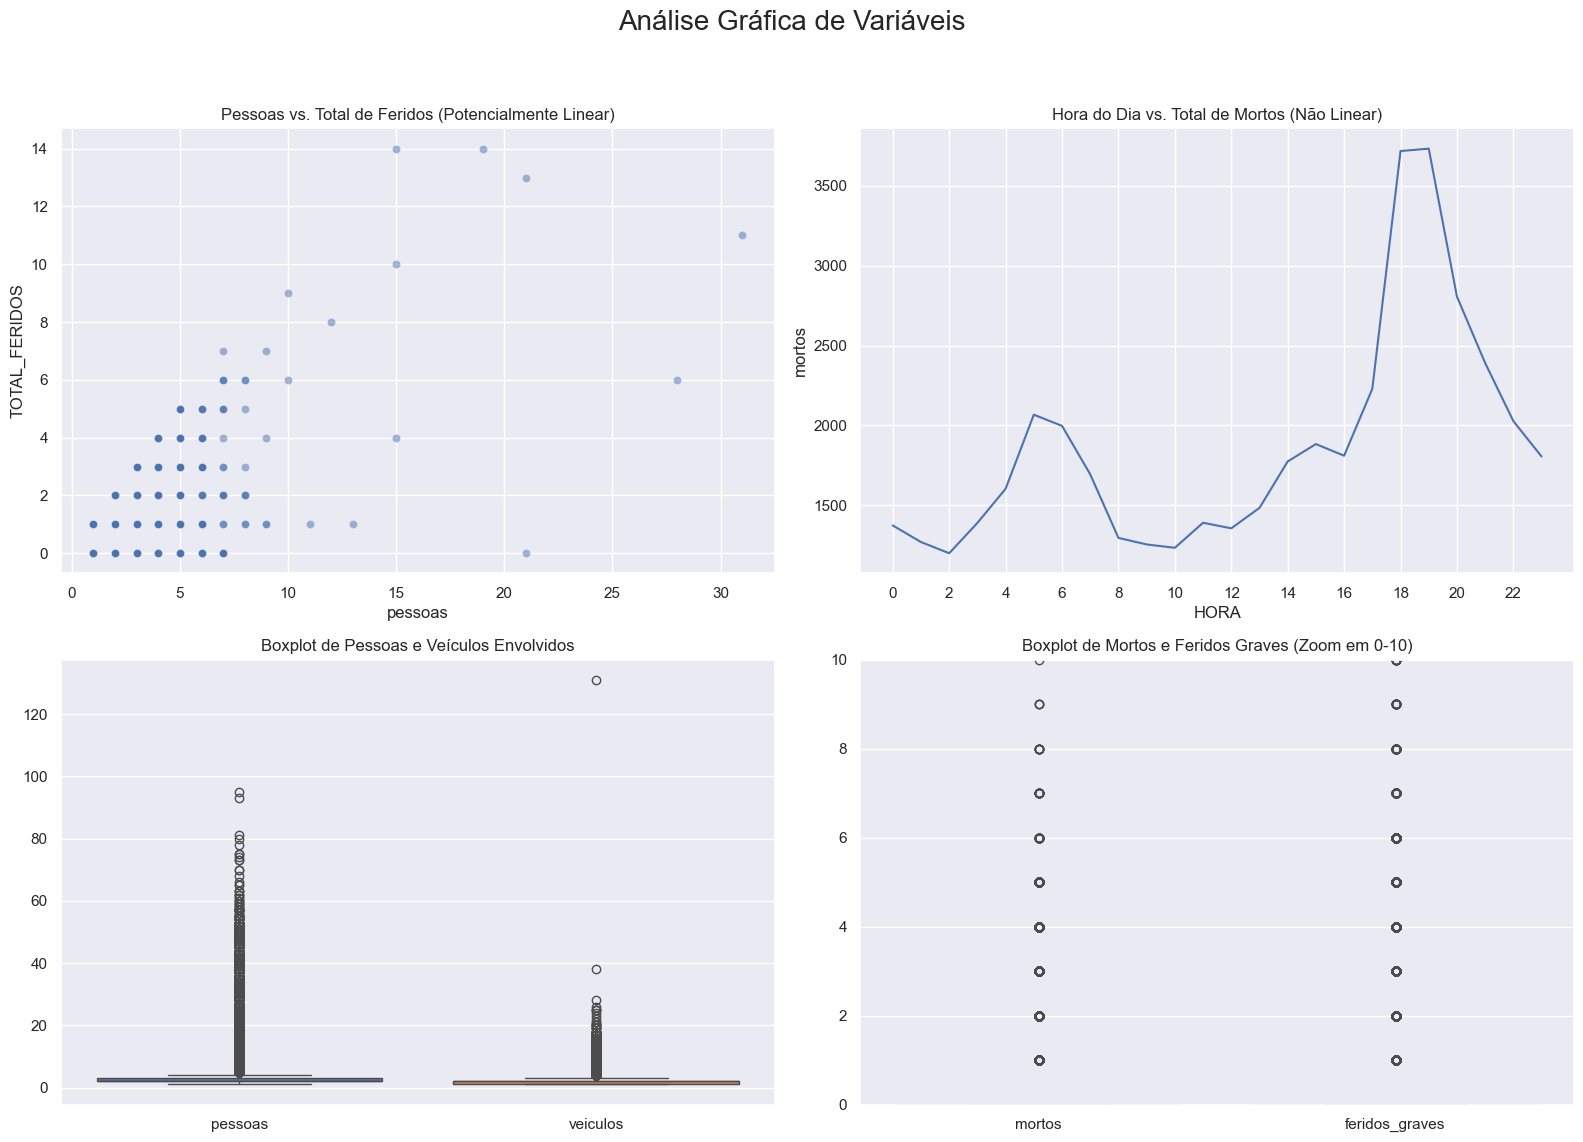

✅ Gráficos gerados.


In [25]:
# 1d) e 1g) GRÁFICOS PARA ANÁLISE (SCATTER PLOT E BOXPLOT)

print("\n--- Gerando Gráficos de Análise ---")

# Criando uma figura para os gráficos
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Análise Gráfica de Variáveis', fontsize=20)

# 1. Relação Linear: Pessoas vs Total de Feridos
sns.scatterplot(data=df.sample(2000), x='pessoas', y='TOTAL_FERIDOS', ax=axes[0, 0], alpha=0.5)
axes[0, 0].set_title('Pessoas vs. Total de Feridos (Potencialmente Linear)')
axes[0, 0].grid(True)

# 2. Relação Não-Linear: Hora do Dia vs Mortos
sns.lineplot(data=df, x='HORA', y='mortos', ax=axes[0, 1], estimator='sum', errorbar=None)
axes[0, 1].set_title('Hora do Dia vs. Total de Mortos (Não Linear)')
axes[0, 1].set_xticks(range(0, 24, 2))
axes[0, 1].grid(True)

# 3. Boxplot para Pessoas e Veículos
sns.boxplot(data=df[['pessoas', 'veiculos']], ax=axes[1, 0])
axes[1, 0].set_title('Boxplot de Pessoas e Veículos Envolvidos')

# 4. Boxplot para Mortos e Feridos Graves (foco na severidade)
# Usando ylim para focar nos valores mais comuns, pois os outliers são extremos
sns.boxplot(data=df[['mortos', 'feridos_graves']], ax=axes[1, 1])
axes[1, 1].set_ylim(0, 10) # Ajuste o limite se necessário
axes[1, 1].set_title('Boxplot de Mortos e Feridos Graves (Zoom em 0-10)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("✅ Gráficos gerados.")


--- Matriz de Covariância ---
                 pessoas    mortos  feridos_leves  feridos_graves    ilesos  \
pessoas         4.082278  0.134373       1.048484        0.313466  2.310201   
mortos          0.134373  0.113889      -0.014992        0.020696 -0.006024   
feridos_leves   1.048484 -0.014992       1.179791       -0.034657 -0.030042   
feridos_graves  0.313466  0.020696      -0.034657        0.370019 -0.047374   
ilesos          2.310201 -0.006024      -0.030042       -0.047374  2.403310   
veiculos        0.975840  0.044987       0.021121        0.047270  0.562844   

                veiculos  
pessoas         0.975840  
mortos          0.044987  
feridos_leves   0.021121  
feridos_graves  0.047270  
ilesos          0.562844  
veiculos        1.179255  

--- Matriz de Correlação de Pearson ---
                 pessoas    mortos  feridos_leves  feridos_graves    ilesos  \
pessoas         1.000000  0.197070       0.477758        0.255051  0.737553   
mortos          0.197070  1

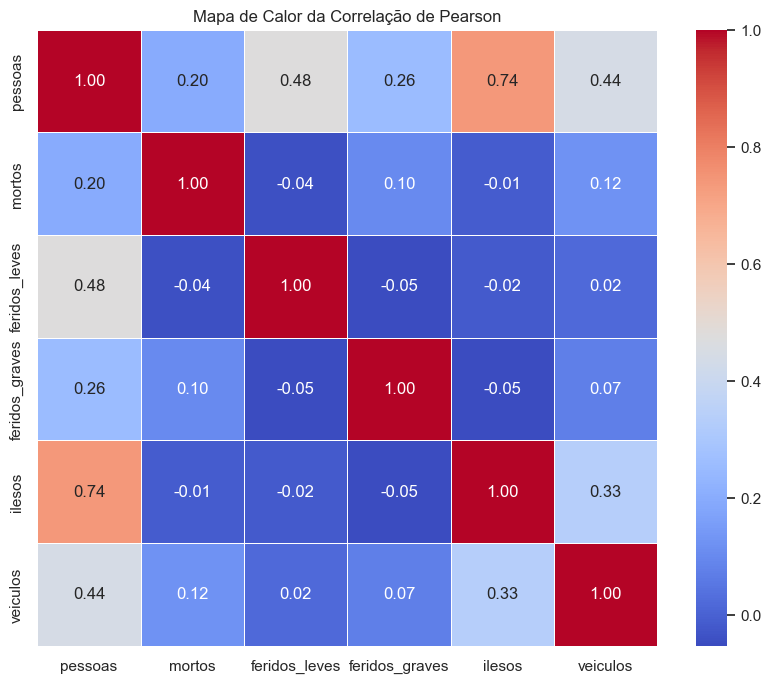

 Log salvo em: analise_estatistica_logs\01e_correlacao_pearson.txt


In [26]:
# 1e) CÁLCULO DE COVARIÂNCIA E CORRELAÇÃO DE PEARSON

# Selecionando um subconjunto de colunas numéricas para a análise
numeric_cols_corr = ['pessoas', 'mortos', 'feridos_leves', 'feridos_graves', 'ilesos', 'veiculos']
df_corr = df[numeric_cols_corr]

# 1. Matriz de Covariância
matriz_cov = df_corr.cov()
print("\n--- Matriz de Covariância ---")
print(matriz_cov)

# 2. Matriz de Correlação de Pearson
matriz_corr_pearson = df_corr.corr(method='pearson')
print("\n--- Matriz de Correlação de Pearson ---")
print(matriz_corr_pearson)

# 3. Visualização da Matriz de Correlação com um Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr_pearson, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Mapa de Calor da Correlação de Pearson')
plt.show()

# --- Salvando os resultados em um log ---
log_content_corr = "Matriz de Covariância:\n" + matriz_cov.to_string() + \
                   "\n\nMatriz de Correlação de Pearson:\n" + matriz_corr_pearson.to_string()
save_log('01e_correlacao_pearson.txt', log_content_corr)


--- Matriz de Correlação de Spearman ---
                 pessoas    mortos  feridos_leves  feridos_graves    ilesos  \
pessoas         1.000000  0.131007       0.259039        0.143106  0.561098   
mortos          0.131007  1.000000      -0.177555        0.018402 -0.064612   
feridos_leves   0.259039 -0.177555       1.000000       -0.288891 -0.204158   
feridos_graves  0.143106  0.018402      -0.288891        1.000000 -0.124560   
ilesos          0.561098 -0.064612      -0.204158       -0.124560  1.000000   
veiculos        0.698979  0.117402      -0.018857        0.079692  0.498493   

                veiculos  
pessoas         0.698979  
mortos          0.117402  
feridos_leves  -0.018857  
feridos_graves  0.079692  
ilesos          0.498493  
veiculos        1.000000  


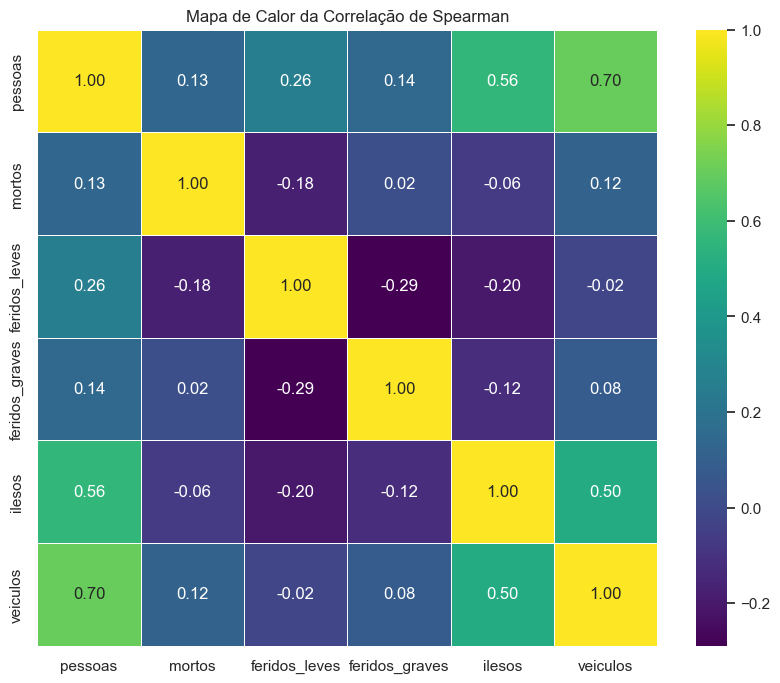

 Log salvo em: analise_estatistica_logs\01f_correlacao_spearman.txt


In [27]:
# 1f) CÁLCULO DO COEFICIENTE DE CORRELAÇÃO DE SPEARMAN

# Usando as mesmas colunas da análise anterior
matriz_corr_spearman = df_corr.corr(method='spearman')
print("\n--- Matriz de Correlação de Spearman ---")
print(matriz_corr_spearman)

# Visualização da Matriz de Correlação de Spearman
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr_spearman, annot=True, cmap='viridis', fmt='.2f', linewidths=.5)
plt.title('Mapa de Calor da Correlação de Spearman')
plt.show()

# --- Salvando os resultados em um log ---
log_content_spearman = "Matriz de Correlação de Spearman:\n" + matriz_corr_spearman.to_string()
save_log('01f_correlacao_spearman.txt', log_content_spearman)

ATV 5

In [28]:
# 2) TÉCNICAS DE AMOSTRAGEM

# Média populacional real para comparação
media_populacional_pessoas = df['pessoas'].mean()
tamanho_amostra = 500  # Definindo um tamanho de amostra para os exemplos

# Dicionário para armazenar resultados
sampling_results = {'Média Populacional': media_populacional_pessoas}

# a) Amostragem Aleatória Simples
amostra_simples = df['pessoas'].sample(n=tamanho_amostra, random_state=42)
media_simples = amostra_simples.mean()
sampling_results['Amostragem Simples'] = media_simples

# b) Amostragem Sistemática
step = len(df) // tamanho_amostra
indices_sistematicos = np.arange(0, len(df), step=step)
amostra_sistematica = df.iloc[indices_sistematicos]['pessoas']
media_sistematica = amostra_sistematica.mean()
sampling_results['Amostragem Sistemática'] = media_sistematica

# c) Amostragem Estratificada (por UF)
# Usando train_test_split para uma amostragem estratificada fácil
_, amostra_estratificada_df, _, _ = train_test_split(
    df, df['uf'], test_size=tamanho_amostra/len(df), stratify=df['uf'], random_state=42
)
media_estratificada = amostra_estratificada_df['pessoas'].mean()
sampling_results['Amostragem Estratificada (por UF)'] = media_estratificada

# d) Amostragem por Conglomerados (por Município)
municipios = df['municipio'].unique()
conglomerados_selecionados = np.random.choice(municipios, size=15, replace=False) # 15 municípios aleatórios
amostra_conglomerados_df = df[df['municipio'].isin(conglomerados_selecionados)]
media_conglomerados = amostra_conglomerados_df['pessoas'].mean()
sampling_results['Amostragem por Conglomerados (15 Municípios)'] = media_conglomerados

print("--- Comparação das Médias de Amostragem ---")
for metodo, media in sampling_results.items():
    print(f"  - {metodo}: {media:.4f}")

# e) Cálculo do Tamanho da Amostra
N = len(df)  # Tamanho da população
Z = 1.96     # Nível de confiança de 95%
p = 0.5      # Proporção populacional (pior caso)
e = 0.05     # Margem de erro de 5%

tamanho_amostra_calculado = (Z**2 * p * (1-p)) / (e**2)
# Fórmula de correção para populações finitas
tamanho_amostra_ajustado = tamanho_amostra_calculado / (1 + (tamanho_amostra_calculado - 1) / N)

print(f"\n--- Cálculo do Tamanho da Amostra ---")
print(f"Para uma população de {N}, com 95% de confiança e margem de erro de 5%,")
print(f"o tamanho de amostra suficiente é de aproximadamente: {int(round(tamanho_amostra_ajustado, 0))} registros.")
sampling_results['Tamanho de Amostra Calculado'] = int(round(tamanho_amostra_ajustado, 0))

# --- Salvando os resultados em um log ---
log_content_sampling = "Análise de Técnicas de Amostragem\n\n"
for metodo, media in sampling_results.items():
    log_content_sampling += f"- {metodo}: {media if isinstance(media, int) else f'{media:.4f}'}\n"
save_log('02_amostragem.txt', log_content_sampling)

--- Comparação das Médias de Amostragem ---
  - Média Populacional: 2.5255
  - Amostragem Simples: 2.5680
  - Amostragem Sistemática: 2.4711
  - Amostragem Estratificada (por UF): 2.5340
  - Amostragem por Conglomerados (15 Municípios): 2.3772

--- Cálculo do Tamanho da Amostra ---
Para uma população de 560138, com 95% de confiança e margem de erro de 5%,
o tamanho de amostra suficiente é de aproximadamente: 384 registros.
 Log salvo em: analise_estatistica_logs\02_amostragem.txt


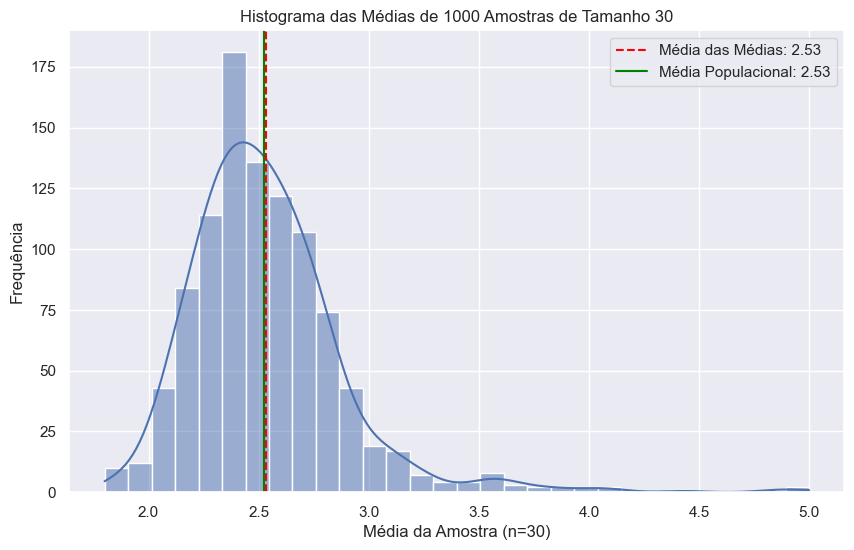

In [29]:
# 3) TEOREMA DO LIMITE CENTRAL - AMOSTRAS n=30

n_amostras = 1000
tamanho_amostra_tlc = 30
medias_amostras_30 = []

for i in range(n_amostras):
    amostra = df['pessoas'].sample(n=tamanho_amostra_tlc)
    medias_amostras_30.append(amostra.mean())

# Plotando o histograma das médias
plt.figure(figsize=(10, 6))
sns.histplot(medias_amostras_30, kde=True, bins=30)
plt.title(f'Histograma das Médias de {n_amostras} Amostras de Tamanho {tamanho_amostra_tlc}')
plt.xlabel('Média da Amostra (n=30)')
plt.ylabel('Frequência')
plt.axvline(np.mean(medias_amostras_30), color='red', linestyle='--', label=f'Média das Médias: {np.mean(medias_amostras_30):.2f}')
plt.axvline(df['pessoas'].mean(), color='green', linestyle='-', label=f'Média Populacional: {df["pessoas"].mean():.2f}')
plt.legend()
plt.show()

In [30]:
# 4) COMPARANDO MÉDIAS COM DIFERENTES TAMANHOS DE AMOSTRA

tamanhos = [10, 100, 1000, 10000]
resultados_tamanhos = {'Média Populacional': df['pessoas'].mean()}

for n in tamanhos:
    media_amostral = df['pessoas'].sample(n=n, random_state=42).mean()
    resultados_tamanhos[f'Média (n={n})'] = media_amostral

print("--- Comparação de Médias por Tamanho de Amostra ---")
for tamanho, media in resultados_tamanhos.items():
    print(f"  - {tamanho}: {media:.4f}")
    
# --- Salvando os resultados em um log ---
log_content_sizes = "Comparação de Médias por Tamanho de Amostra\n\n"
for tamanho, media in resultados_tamanhos.items():
    log_content_sizes += f"- {tamanho}: {media:.4f}\n"
save_log('04_tamanhos_amostra.txt', log_content_sizes)

--- Comparação de Médias por Tamanho de Amostra ---
  - Média Populacional: 2.5255
  - Média (n=10): 2.9000
  - Média (n=100): 2.6500
  - Média (n=1000): 2.4920
  - Média (n=10000): 2.5086
 Log salvo em: analise_estatistica_logs\04_tamanhos_amostra.txt


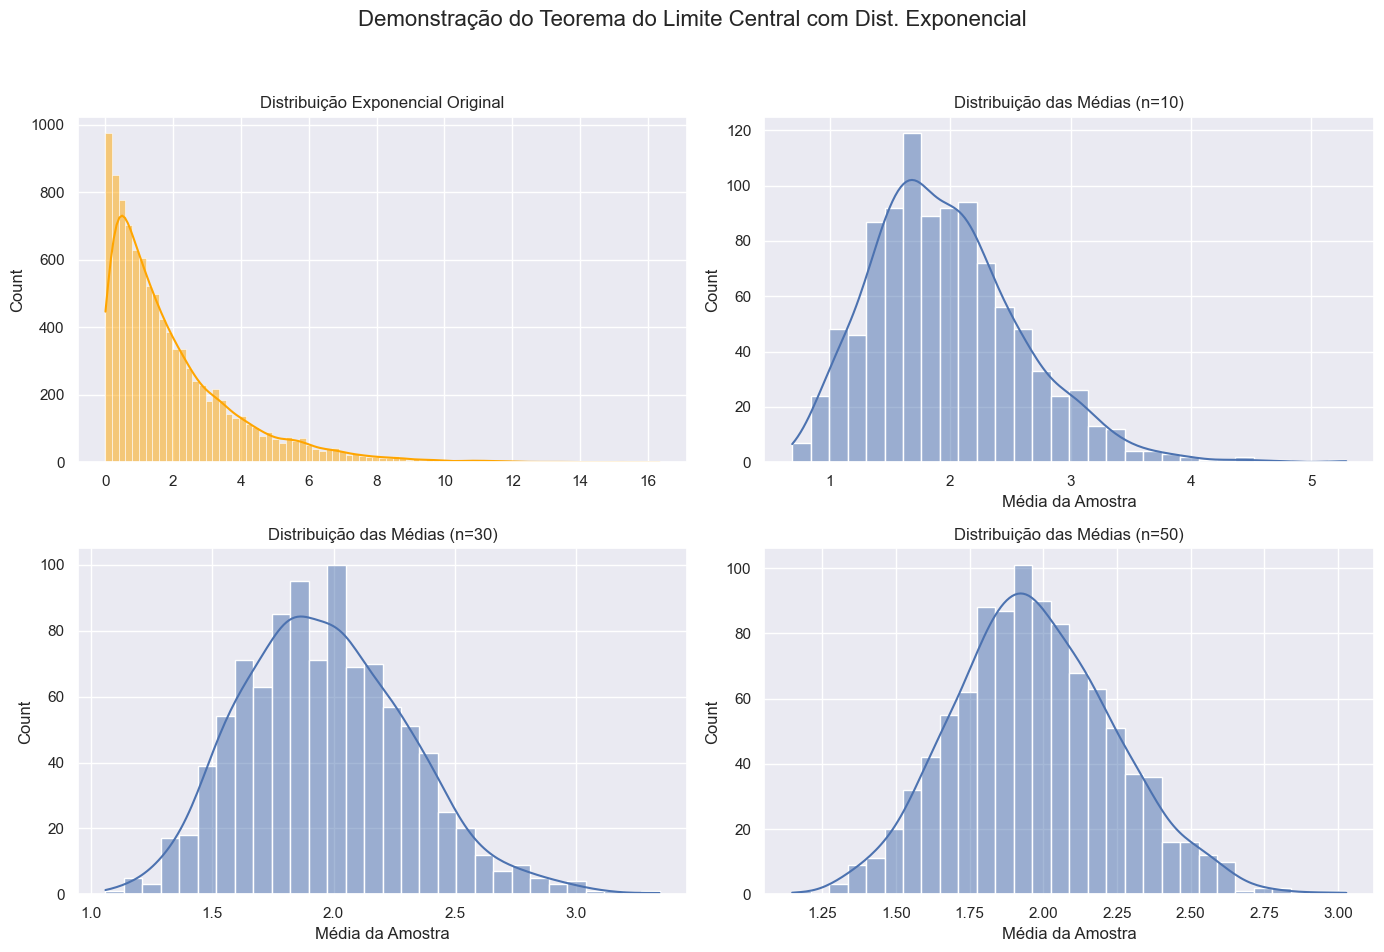

In [31]:
# 5) TLC COM DISTRIBUIÇÃO EXPONENCIAL

# Gerar 1000 amostras de uma distribuição exponencial
np.random.seed(42)
dados_exp = np.random.exponential(scale=2, size=10000)

tamanhos_exp = [10, 30, 50]
n_amostras_exp = 1000

# Plotar a distribuição original e as distribuições das médias
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Demonstração do Teorema do Limite Central com Dist. Exponencial', fontsize=16)

# Distribuição original
sns.histplot(dados_exp, kde=True, ax=axes[0, 0], color='orange')
axes[0, 0].set_title('Distribuição Exponencial Original')

# Distribuições das médias
plot_pos = [(0, 1), (1, 0), (1, 1)]
for i, n in enumerate(tamanhos_exp):
    medias_amostrais_exp = [np.mean(np.random.choice(dados_exp, n)) for _ in range(n_amostras_exp)]
    ax = axes[plot_pos[i]]
    sns.histplot(medias_amostrais_exp, kde=True, ax=ax, bins=30)
    ax.set_title(f'Distribuição das Médias (n={n})')
    ax.set_xlabel('Média da Amostra')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

--- Ranking das Melhores Distribuições (menor erro primeiro) ---
          sumsquare_error           aic           bic  kl_div  ks_statistic  \
expon            0.476252  13882.501573  13901.872556     inf      0.833408   
chi2             1.761333   4488.080672   4517.137146     inf      0.833408   
rayleigh         3.389295  59693.086368  59712.457350     inf      0.553700   
norm             3.967697  70947.638067  70967.009049     inf      0.462298   
exponpow         4.200864   1483.896175   1512.952649     inf      0.827617   

          ks_pvalue  
expon           0.0  
chi2            0.0  
rayleigh        0.0  
norm            0.0  
exponpow        0.0  

Melhor distribuição encontrada: expon


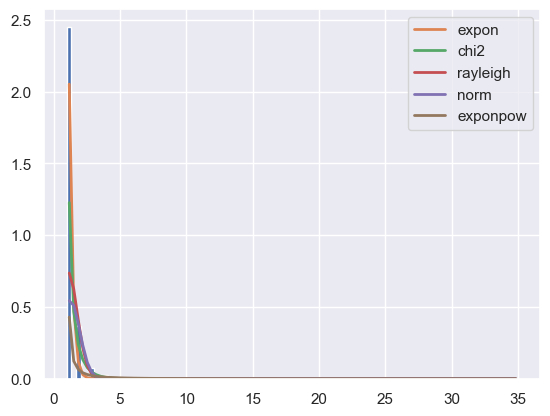

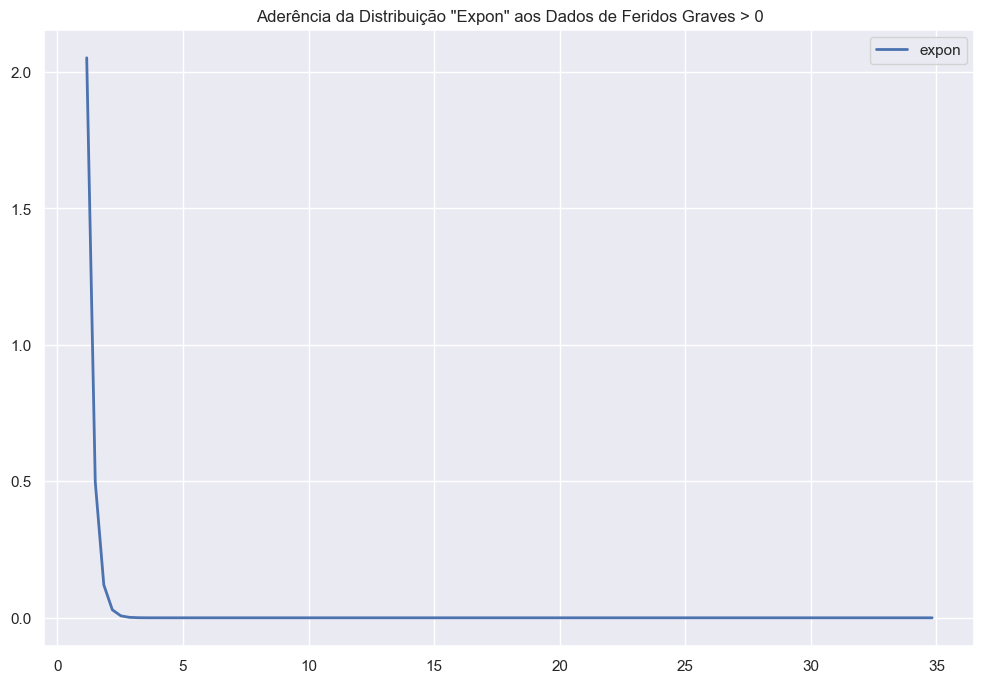

 Log salvo em: analise_estatistica_logs\06_fitter_ranking.txt


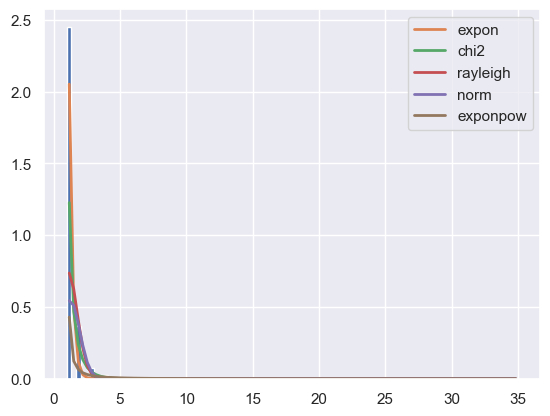

In [32]:
# 6) RANKING DE ADERÊNCIA DE DISTRIBUIÇÕES COM FITTER (VERSÃO CORRIGIDA)

# É recomendado instalar a biblioteca se ainda não tiver
# !pip install fitter

# Vamos analisar a distribuição do número de feridos graves,
# mas apenas para acidentes onde houve pelo menos um.
dados_para_fit = df[df['feridos_graves'] > 0]['feridos_graves']

# Utilizando Fitter para encontrar a melhor distribuição
f = Fitter(dados_para_fit,
           distributions=get_common_distributions(),
           timeout=120) # Aumentar timeout para datasets grandes
f.fit()

# a) Apresentando o ranking e o gráfico
print("--- Ranking das Melhores Distribuições (menor erro primeiro) ---")
print(f.summary())

# CORREÇÃO APLICADA AQUI
# Pegamos o nome da melhor distribuição e o colocamos em uma lista
best_dist_dict = f.get_best(method='sumsquare_error')
best_dist_name = list(best_dist_dict.keys())[0]
print(f"\nMelhor distribuição encontrada: {best_dist_name}")


# b) Relatando impressões (o gráfico ajuda nisso)
plt.figure(figsize=(12, 8))
# Usamos o nome da melhor distribuição dentro de uma lista
f.plot_pdf(names=[best_dist_name], Nbest=1, lw=2) 
plt.title(f'Aderência da Distribuição "{best_dist_name.capitalize()}" aos Dados de Feridos Graves > 0')
plt.show()

# --- Salvando os resultados em um log ---
log_content_fitter = "Ranking de Aderência (sumsquare_error):\n\n" + f.summary().to_string()
save_log('06_fitter_ranking.txt', log_content_fitter)